In [ ]:
#MOUNTING DRIVE
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
import torch
print(torch.cuda.is_available())

True


In [ ]:
print(torch.cuda.get_device_name(0))

Tesla T4


In [ ]:
#LOADING THE DATASET
from datasets import load_dataset
imdb_dataset = load_dataset("imdb")

In [ ]:
#SAVING THE DATASET TO DRIVE
imdb_dataset.save_to_disk("/content/drive/MyDrive/imdb_dataset")

In [ ]:
import os
os.listdir("/content/drive/MyDrive/imdb_dataset")

['dataset_dict.json', 'train', 'test', 'unsupervised']

In [ ]:
from datasets import load_from_disk
dataset = load_from_disk("/content/drive/MyDrive/imdb_dataset")

In [ ]:
print(dataset)#PRINTING THE CONTENTS OF DATASET

DatasetDict({
    train: Dataset({
        features: ['text', 'label'],
        num_rows: 25000
    })
    test: Dataset({
        features: ['text', 'label'],
        num_rows: 25000
    })
    unsupervised: Dataset({
        features: ['text', 'label'],
        num_rows: 50000
    })
})


#DATA UNDERSTANDING

In [ ]:
print(dataset.keys())

dict_keys(['train', 'test', 'unsupervised'])


In [ ]:
#EXTRACTING ONLY THE TRAIN DATASET AND TEST DATASET
train_dataset = dataset['train']
test_dataset = dataset['test']
print(train_dataset.features)
print(test_dataset.features)

{'text': Value('string'), 'label': ClassLabel(names=['neg', 'pos'])}
{'text': Value('string'), 'label': ClassLabel(names=['neg', 'pos'])}


In [ ]:
print(train_dataset[0])#PRINTING ONLY THE FIRST ELEMENT OF TRAIN DATASET

{'text': 'I rented I AM CURIOUS-YELLOW from my video store because of all the controversy that surrounded it when it was first released in 1967. I also heard that at first it was seized by U.S. customs if it ever tried to enter this country, therefore being a fan of films considered "controversial" I really had to see this for myself.<br /><br />The plot is centered around a young Swedish drama student named Lena who wants to learn everything she can about life. In particular she wants to focus her attentions to making some sort of documentary on what the average Swede thought about certain political issues such as the Vietnam War and race issues in the United States. In between asking politicians and ordinary denizens of Stockholm about their opinions on politics, she has sex with her drama teacher, classmates, and married men.<br /><br />What kills me about I AM CURIOUS-YELLOW is that 40 years ago, this was considered pornographic. Really, the sex and nudity scenes are few and far be

In [ ]:
print(train_dataset[0]['text'])
print(train_dataset[0]['label'])

I rented I AM CURIOUS-YELLOW from my video store because of all the controversy that surrounded it when it was first released in 1967. I also heard that at first it was seized by U.S. customs if it ever tried to enter this country, therefore being a fan of films considered "controversial" I really had to see this for myself.<br /><br />The plot is centered around a young Swedish drama student named Lena who wants to learn everything she can about life. In particular she wants to focus her attentions to making some sort of documentary on what the average Swede thought about certain political issues such as the Vietnam War and race issues in the United States. In between asking politicians and ordinary denizens of Stockholm about their opinions on politics, she has sex with her drama teacher, classmates, and married men.<br /><br />What kills me about I AM CURIOUS-YELLOW is that 40 years ago, this was considered pornographic. Really, the sex and nudity scenes are few and far between, eve

In [ ]:
print(train_dataset.features['text'])
print(train_dataset.features['label'])

Value('string')
ClassLabel(names=['neg', 'pos'])


In [ ]:
for i in range(10):#PRINTING THE FIRST 10 ELEMENTS OF THE TRAIN DATASET
  print(train_dataset[i]['text'])
  print(train_dataset[i]['label'])

I rented I AM CURIOUS-YELLOW from my video store because of all the controversy that surrounded it when it was first released in 1967. I also heard that at first it was seized by U.S. customs if it ever tried to enter this country, therefore being a fan of films considered "controversial" I really had to see this for myself.<br /><br />The plot is centered around a young Swedish drama student named Lena who wants to learn everything she can about life. In particular she wants to focus her attentions to making some sort of documentary on what the average Swede thought about certain political issues such as the Vietnam War and race issues in the United States. In between asking politicians and ordinary denizens of Stockholm about their opinions on politics, she has sex with her drama teacher, classmates, and married men.<br /><br />What kills me about I AM CURIOUS-YELLOW is that 40 years ago, this was considered pornographic. Really, the sex and nudity scenes are few and far between, eve

In [ ]:
for i in range(5):# CHECKING THE LENGTH OF TOP 5 REVIEWS
  review = train_dataset[i]['text']
  print(f'Review length of {i} : {len(review)}')


Review length of 0 : 1640
Review length of 1 : 1294
Review length of 2 : 528
Review length of 3 : 706
Review length of 4 : 1814


In [ ]:
positive_count = 0
negative_count = 0
for rev in train_dataset:  #CHECKING THE COUNT OF TOTAL POSITIVE AND NEGATIVE REVIEWS
  if rev['label'] == 1:
    positive_count +=1
  else:
    negative_count +=1

print("Positive review counts", positive_count)
print("Negative review counts", negative_count)

Positive review counts 12500
Negative review counts 12500


#DATA PREPROCESSING

In [ ]:
from sklearn.model_selection import train_test_split
# SPLITTING THE TRAIN DATASET FOR TRAINING AND VALIDATION
x = list(train_dataset["text"])
y = list(train_dataset["label"])

train_text, val_text, train_label, val_label = train_test_split(x, y, test_size = 0.2, random_state = 42, stratify = y)

print('Train size:', len(train_text))
print('Validation size:', len(val_text))

Train size: 20000
Validation size: 5000


In [ ]:
test_text = list(test_dataset['text'])
test_label = list(test_dataset['label'])


In [ ]:
type(train_label[0])

int

In [ ]:
#TEXT PREPROCESSING
from bs4 import BeautifulSoup
import re
#DEFINING METHOD FOR TEXT PREPROCESSING
def preprocessing(text):
  text = text.lower()#LOWERING THE TEXT
  text = BeautifulSoup(text, 'html.parser').get_text()#REMOVING HTML HAST TAGS
  text = re.sub(r'\s+',' ', text).strip()#REMOVING MULTIPLE SPACES
  return {'clean_text': text }


In [ ]:
#PASSING THE TEXT DATA INTO THE PREPROCESSING METHOD
train_text = [preprocessing(text) for text in train_text]
val_text = [preprocessing(text) for text in val_text]
test_text = [preprocessing(text) for text in test_text]
print('Train dataset',train_text)
print('Validation dataset', val_text)
print('Test dataset', test_text)

In [ ]:
train_texts = [sample['clean_text'] for sample in train_text]
val_texts = [sample['clean_text'] for sample in val_text]
test_texts = [sample['clean_text'] for sample in test_text]

In [ ]:
print(train_texts[0])

i have always been a huge james bond fanatic! i have seen almost all of the films except for die another day, and the world is not enough. the graphic's for everything or nothing are breathtaking! the voice talents......... wow! i love pierce brosnan! he is finally bond in a video game! he is bond! i enjoyed the past bond games: goldeneye, the world is not enough, agent under fire, and nightfire. this one is definitely the best! finally, mr. brosnan, (may i call him mr. brosnan as a sign of respect? yes i can!) he was phenomenally exciting to hear in a video game....... at long last! duh! i've seen him perform with robin williams, and let me tell you, they make a great team. pierce brosnan is funny, wickedly handsome ( i mean to say wickedly in a good way,) and just one of those actor's who you would want to walk up to and wrap your arms around and hug, saying: "pierce brosnan, thank you for being james bond," "if it wasn't for you, i wouldn't know who james bond is." he's a great acto

In [ ]:
print(test_texts[0])

i love sci-fi and am willing to put up with a lot. sci-fi movies/tv are usually underfunded, under-appreciated and misunderstood. i tried to like this, i really did, but it is to good tv sci-fi as babylon 5 is to star trek (the original). silly prosthetics, cheap cardboard sets, stilted dialogues, cg that doesn't match the background, and painfully one-dimensional characters cannot be overcome with a 'sci-fi' setting. (i'm sure there are those of you out there who think babylon 5 is good sci-fi tv. it's not. it's clichéd and uninspiring.) while us viewers might like emotion and character development, sci-fi is a genre that does not take itself seriously (cf. star trek). it may treat important issues, yet not as a serious philosophy. it's really difficult to care about the characters here as they are not simply foolish, just missing a spark of life. their actions and reactions are wooden and predictable, often painful to watch. the makers of earth know it's rubbish as they have to alway

In [ ]:
for i in range(5):
  print(train_texts[i])

i have always been a huge james bond fanatic! i have seen almost all of the films except for die another day, and the world is not enough. the graphic's for everything or nothing are breathtaking! the voice talents......... wow! i love pierce brosnan! he is finally bond in a video game! he is bond! i enjoyed the past bond games: goldeneye, the world is not enough, agent under fire, and nightfire. this one is definitely the best! finally, mr. brosnan, (may i call him mr. brosnan as a sign of respect? yes i can!) he was phenomenally exciting to hear in a video game....... at long last! duh! i've seen him perform with robin williams, and let me tell you, they make a great team. pierce brosnan is funny, wickedly handsome ( i mean to say wickedly in a good way,) and just one of those actor's who you would want to walk up to and wrap your arms around and hug, saying: "pierce brosnan, thank you for being james bond," "if it wasn't for you, i wouldn't know who james bond is." he's a great acto

In [ ]:
from collections import Counter

MAX_VOCAB = 20000
MAX_LEN = 150

#Tokenization
def tokenize(text):
  return text.split()

train_tokens = [tokenize(i) for i in train_texts]
val_tokens = [tokenize(i) for i in val_texts]

In [ ]:
#Vocabulary building
counter = Counter()

for tokens in train_tokens:
  counter.update(tokens)

vocab = {"<PAD>":0, "<UNK>":1}

for i, (word,_) in enumerate(counter.most_common(MAX_VOCAB-2)):
  vocab[word] = i + 2
print("Vocabulary Size:", len(vocab))

Vocabulary Size: 20000


In [ ]:
#Encoding + Padding

def encode(tokens):

  encoded = [vocab.get(word, vocab["<UNK>"]) for word in tokens]
  #Truncating
  encoded = encoded[:MAX_LEN]
  #Padding
  encoded +=[vocab["<PAD>"]] * (MAX_LEN - len(encoded))
  return encoded

train_encoded = [encode(i) for i in train_tokens]
val_encoded = [encode(i) for i in val_tokens]

In [ ]:
# Tokenization
test_tokens = [tokenize(t) for t in test_texts]

# Encoding + Padding (using TRAIN vocab)
test_encoded = [encode(t) for t in test_tokens]



In [ ]:
#CONVERTING THE TEXT DATA INTO TENSOR
train_encoded = torch.tensor(train_encoded, dtype=torch.long)
train_label = torch.tensor(train_label, dtype=torch.long)

val_encoded = torch.tensor(val_encoded, dtype=torch.long)
val_label = torch.tensor(val_label, dtype=torch.long)

In [ ]:
test_encoded = torch.tensor(test_encoded, dtype=torch.long)
test_label = torch.tensor(test_label, dtype=torch.long)

/tmp/ipykernel_867/1029147934.py:1: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.detach().clone() or sourceTensor.detach().clone().requires_grad_(True), rather than torch.tensor(sourceTensor).
  test_encoded = torch.tensor(test_encoded, dtype=torch.long)
/tmp/ipykernel_867/1029147934.py:2: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.detach().clone() or sourceTensor.detach().clone().requires_grad_(True), rather than torch.tensor(sourceTensor).
  test_label = torch.tensor(test_label, dtype=torch.long)


In [ ]:
#CREATING DATA LOADER
import torch
from torch.utils.data import Dataset, TensorDataset, DataLoader

class IMDBDataset(Dataset):

    def __init__(self, texts, labels):
        self.texts = texts
        self.labels = labels

    def __len__(self):
        return len(self.texts)

    def __getitem__(self, idx):
        return self.texts[idx], self.labels[idx]

In [ ]:
train_data = IMDBDataset(train_encoded, train_label)

val_data = IMDBDataset(val_encoded, val_label)

test_data = IMDBDataset(test_encoded, test_label)

In [ ]:
BATCH_SIZE = 32

train_loader = DataLoader(train_data, batch_size = BATCH_SIZE, shuffle = True)
val_loader = DataLoader(val_data, batch_size = BATCH_SIZE, shuffle = False)
test_loader = DataLoader(test_data, batch_size = BATCH_SIZE, shuffle = False)


In [ ]:
for i, j in test_loader:
  print(i.shape)
  print(j.shape)
  break

torch.Size([32, 150])
torch.Size([32])


#CUSTOM LSTM MODEL BUILDING

In [ ]:
import torch
import torch.nn as nn

class CustomLSTM(nn.Module):

    def __init__(self, vocab_size, embed_dim=128, hidden_dim=128):

        super(CustomLSTM, self).__init__()

        self.embedding = nn.Embedding(
            num_embeddings=vocab_size,
            embedding_dim=embed_dim,
            padding_idx=0
        )

        self.lstm = nn.LSTM(
            input_size=embed_dim,
            hidden_size=hidden_dim,
            batch_first=True
        )

        self.fc = nn.Linear(hidden_dim, 2)

    def forward(self, x):

        embedded = self.embedding(x)

        lstm_out, (hidden, cell) = self.lstm(embedded)

        out = hidden[-1]

        logits = self.fc(out)

        return logits

In [ ]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

model = CustomLSTM(vocab_size=len(vocab)).to(device)

In [ ]:
import torch.optim as optim
#OPTIMIZER
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=0.001)

In [ ]:
#DEFINING THE TRAINING LOOP
def train_one_epoch(model, loader, optimizer, criterion):

    model.train()

    total_loss = 0
    correct = 0
    total = 0

    for X, y in loader:

        X, y = X.to(device), y.to(device)

        optimizer.zero_grad()

        outputs = model(X)

        loss = criterion(outputs, y)

        loss.backward()

        optimizer.step()

        total_loss += loss.item()

        # accuracy
        preds = torch.argmax(outputs, dim=1)

        correct += (preds == y).sum().item()
        total += y.size(0)

    return total_loss / len(loader), correct / total

In [ ]:
#DEFINING THE VALIDATION LOOP
def validation(model, loader, criterion):

    model.eval()

    total_loss = 0
    correct = 0
    total = 0

    with torch.no_grad():

        for X, y in loader:

            X, y = X.to(device), y.to(device)

            outputs = model(X)

            loss = criterion(outputs, y)

            total_loss += loss.item()

            preds = torch.argmax(outputs, dim=1)

            correct += (preds == y).sum().item()
            total += y.size(0)

    return total_loss / len(loader), correct / total

In [ ]:
#DEFINING EPOCHS AND TRIANING THE MODEL
EPOCHS = 5

for epoch in range(EPOCHS):

    train_loss, train_acc = train_one_epoch(
        model, train_loader, optimizer, criterion)

    val_loss, val_acc = validation(
        model, val_loader, criterion)

    print(f"Epoch {epoch+1}/{EPOCHS}")
    print(f"Train Loss: {train_loss:.4f} | Train Acc: {train_acc:.4f}")
    print(f"Val Loss:   {val_loss:.4f} | Val Acc:   {val_acc:.4f}")
    print()
#SAVING THE MODEL
import os
import torch
from google.colab import drive

# Mount Google Drive
drive.mount('/content/drive')
save_dir = "/content/drive/MyDrive/lstm_imdb_model"
os.makedirs(save_dir, exist_ok=True)

model_path = os.path.join(save_dir, "Custom_lstm_sentiment_analysis_model.pth")

torch.save(model.state_dict(), model_path)

print("Model saved at:", model_path)

Epoch 1/5
Train Loss: 0.1178 | Train Acc: 0.9603
Val Loss:   0.5712 | Val Acc:   0.8118

Epoch 2/5
Train Loss: 0.0731 | Train Acc: 0.9766
Val Loss:   0.7154 | Val Acc:   0.8104

Epoch 3/5
Train Loss: 0.0509 | Train Acc: 0.9839
Val Loss:   0.7295 | Val Acc:   0.8144

Epoch 4/5
Train Loss: 0.0295 | Train Acc: 0.9915
Val Loss:   0.8032 | Val Acc:   0.8114

Epoch 5/5
Train Loss: 0.0235 | Train Acc: 0.9931
Val Loss:   0.9353 | Val Acc:   0.8122

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Model saved at: /content/drive/MyDrive/lstm_imdb_model/Custom_lstm_sentiment_analysis_model.pth


#CUSTOM LSTM MODEL EVALUATION

In [ ]:
import torch

def evaluate_test(model, test_loader, criterion):

    model.eval()

    total_loss = 0
    correct = 0
    total = 0

    all_preds = []
    all_labels = []

    with torch.no_grad():

        for X, y in test_loader:

            X, y = X.to(device), y.to(device)

            outputs = model(X)

            loss = criterion(outputs, y)

            total_loss += loss.item()

            preds = torch.argmax(outputs, dim=1)

            correct += (preds == y).sum().item()
            total += y.size(0)

            # store for metrics
            all_preds.extend(preds.cpu().numpy())
            all_labels.extend(y.cpu().numpy())

    accuracy = correct / total

    return total_loss / len(test_loader), accuracy, all_preds, all_labels

CUSTOM LSTM RESULTS

In [ ]:
test_loss, test_acc, y_pred, y_true = evaluate_test(
    model,
    test_loader,
    criterion
)
import torch
import os

save_dir = "/content/drive/MyDrive/lstm_imdb_model"
os.makedirs(save_dir, exist_ok=True)

results_path = os.path.join(save_dir, "CustomLSTM_test_results.pth")

results = {
    "test_loss": test_loss,
    "test_acc": test_acc,
    "y_pred": y_pred,
    "y_true": y_true
}

torch.save(results, results_path)

print("Results saved at:", results_path)
print("Test Loss:", test_loss)
print("Test Accuracy:", test_acc)

Results saved at: /content/drive/MyDrive/lstm_imdb_model/CustomLSTM_test_results.pth
Test Loss: 1.0351467812808988
Test Accuracy: 0.79804


In [ ]:
from sklearn.metrics import classification_report

print(classification_report(y_true, y_pred, target_names=["Negative", "Positive"]))

              precision    recall  f1-score   support

    Negative       0.80      0.80      0.80     12500
    Positive       0.80      0.80      0.80     12500

    accuracy                           0.80     25000
   macro avg       0.80      0.80      0.80     25000
weighted avg       0.80      0.80      0.80     25000



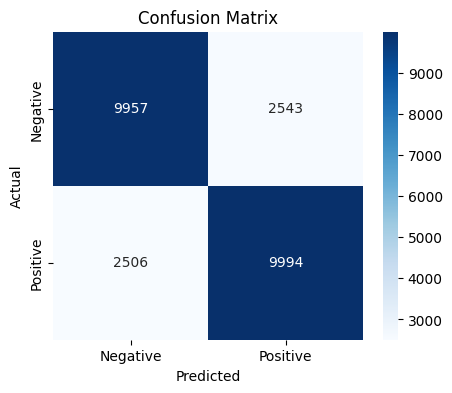

In [ ]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

cm = confusion_matrix(y_true, y_pred)

plt.figure(figsize=(5,4))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
            xticklabels=["Negative", "Positive"],
            yticklabels=["Negative", "Positive"])

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")
plt.show()

#PRETRAINED AWD-LSTM (ULMFiT) MODEL


In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
import torch
from datasets import load_dataset
dataset = load_dataset("imdb")#LOADING THE DATASET

print(dataset)

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:93: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


README.md: 0.00B [00:00, ?B/s]

plain_text/train-00000-of-00001.parquet:   0%|          | 0.00/21.0M [00:00<?, ?B/s]

plain_text/test-00000-of-00001.parquet:   0%|          | 0.00/20.5M [00:00<?, ?B/s]

plain_text/unsupervised-00000-of-00001.p(…):   0%|          | 0.00/42.0M [00:00<?, ?B/s]

Generating train split:   0%|          | 0/25000 [00:00<?, ? examples/s]

Generating test split:   0%|          | 0/25000 [00:00<?, ? examples/s]

Generating unsupervised split:   0%|          | 0/50000 [00:00<?, ? examples/s]

DatasetDict({
    train: Dataset({
        features: ['text', 'label'],
        num_rows: 25000
    })
    test: Dataset({
        features: ['text', 'label'],
        num_rows: 25000
    })
    unsupervised: Dataset({
        features: ['text', 'label'],
        num_rows: 50000
    })
})


In [ ]:
import pandas as pd
#CREATING THE DICTIONARY DATA TO DATAFRAME
train_df = pd.DataFrame({
    "text": dataset["train"]["text"],
    "label": dataset["train"]["label"]
})

test_df = pd.DataFrame({
    "text": dataset["test"]["text"],
    "label": dataset["test"]["label"]
})

In [ ]:
#DATA PREPROCESSING
from bs4 import BeautifulSoup
import re

def clean_text(text):
    text = BeautifulSoup(text, "html.parser").get_text()  # remove HTML
    text = re.sub(r'\s+', ' ', text).strip()              # normalize spaces
    return text

train_df["text"] = train_df["text"].apply(clean_text)
test_df["text"] = test_df["text"].apply(clean_text)

In [ ]:
from fastai.text.all import *
#CREATING DATALOADERS FASTAI WAY
dls_lm = TextDataLoaders.from_df(
    train_df,
    text_col="text",
    is_lm=True,
    valid_pct=0.1,
    seed=42,
    bs=64
)

In [ ]:
#Language Model Training
learn_lm = language_model_learner(
    dls_lm,
    AWD_LSTM,
    drop_mult=0.5,
    metrics=[accuracy, Perplexity()]
)

learn_lm.fit_one_cycle(1, 2e-2)

<div><progress max="105067061" value="105070592"></progress> 100.00% [105070592/105067061 00:02&lt;00:00]</div>

epoch,train_loss,valid_loss,accuracy,perplexity,time
0,4.245176,4.095483,0.280252,60.068336,09:14


In [ ]:
learn_lm.save_encoder("ulmfit_encoder")

In [ ]:
#Text Classifier Training
learn_clas = text_classifier_learner(
    dls_clas,
    AWD_LSTM,
    drop_mult=0.5,
    metrics=accuracy
)

In [ ]:
learn_clas = learn_clas.load_encoder("ulmfit_encoder")

In [ ]:
#TRAINING ULMFiT TEXT CLASSIFICATION MODEL
learn_clas.fit_one_cycle(1, 2e-2)

epoch,train_loss,valid_loss,accuracy,time
0,0.395367,0.345099,0.857800,01:50


In [ ]:
learn_clas.export("ulmfit_classifier_sentiment_analysis_model_export.pkl")

In [ ]:
#TESTING
test_dl = learn_clas.dls.test_dl(test_df, with_labels=True)


In [ ]:
from sklearn.metrics import accuracy_score, classification_report
import numpy as np

# Get predictions from model
preds, targs = learn_clas.get_preds(dl=test_dl)

# Predicted labels
pred_labels = preds.argmax(dim=1).numpy()

# True labels
true_labels = targs.numpy()

# Accuracy
test_accuracy = accuracy_score(true_labels, pred_labels)

print("Test Accuracy:", test_accuracy)

# Classification report
print(classification_report(true_labels, pred_labels))

Test Accuracy: 0.85344
              precision    recall  f1-score   support

           0       0.88      0.82      0.85     12500
           1       0.83      0.89      0.86     12500

    accuracy                           0.85     25000
   macro avg       0.86      0.85      0.85     25000
weighted avg       0.86      0.85      0.85     25000



In [ ]:
from google.colab import drive
drive.mount('/content/drive')
save_path = "/content/drive/MyDrive/ULMFIT_Sentiment_Model"

#SAVING THE MODEL AND ENCODER
import os
os.makedirs(save_path, exist_ok=True)
learn_clas.save_encoder(f"{save_path}/ulmfit_encoder")
learn_clas.export(f"{save_path}/ulmfit_classifier_sentiment_analysis_model_export.pkl")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
#SAVING THE RESULTS
import pandas as pd

# Predicted labels
pred_labels = preds.argmax(dim=1).numpy()

# True labels from test dataframe
true_labels = test_df["label"].values

# Create results dataframe
results_df = pd.DataFrame({
    "text": test_df["text"],
    "true_label": true_labels,
    "pred_label": pred_labels
})

In [ ]:
results_df.to_csv("/content/drive/MyDrive/ulmfit_results.csv", index=False)

In [ ]:
with open("/content/drive/MyDrive/ulmfit_accuracy.txt", "w") as f:
    f.write(f"Test Accuracy: {test_accuracy}")